In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

C:\Users\Jose Miguel\AppData\Local\Temp\ipykernel_13472\2301846823.py:78: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: pd.Series({
C:\Users\Jose Miguel\AppData\Local\Temp\ipykernel_13472\2301846823.py:78: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: pd.Series({


Saved: C:\Users\Jose Miguel\OneDrive\Ambiente de Trabalho\NOVA\TESE\figures\chapter4_point1\Fig_4_1_LondonVolume_2019_2025.png


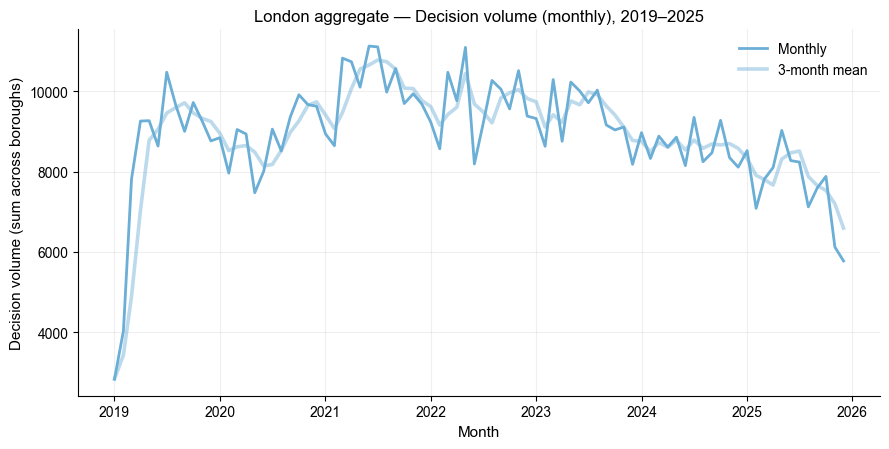

Saved: C:\Users\Jose Miguel\OneDrive\Ambiente de Trabalho\NOVA\TESE\figures\chapter4_point1\Fig_4_2_LondonDecisionTime_2019_2025.png


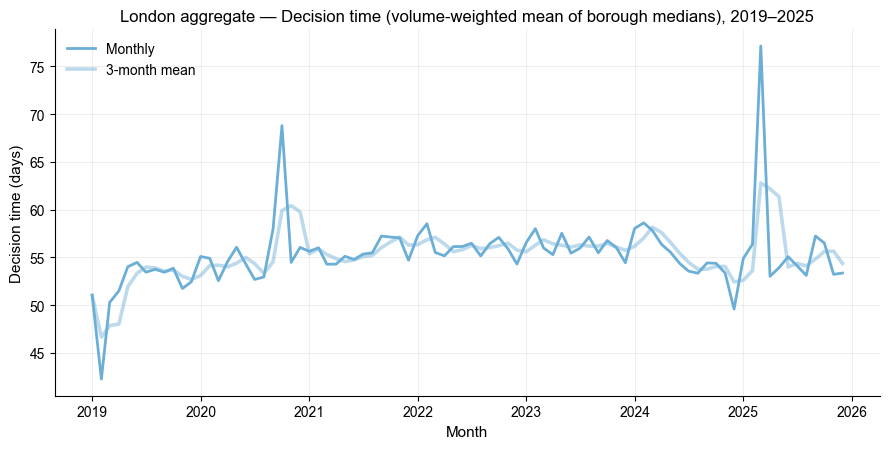

Saved: C:\Users\Jose Miguel\OneDrive\Ambiente de Trabalho\NOVA\TESE\figures\chapter4_point1\Fig_4_3_LondonApprovalRate_2019_2025.png


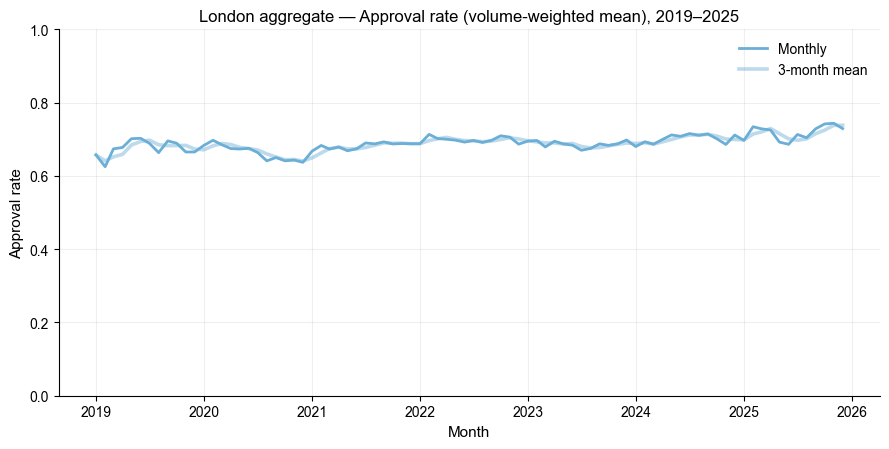

In [1]:
# ============================================
# Chapter 4 — Point 1 (Descriptive analysis)
# ============================================

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# -----------------------------
# CONFIG
# -----------------------------
CSV_PATH = r"C:\Users\Jose Miguel\OneDrive\Ambiente de Trabalho\NOVA\TESE\processed\borough_month_panel_resilience_inputs.csv"

OUT_DIR = r"C:\Users\Jose Miguel\OneDrive\Ambiente de Trabalho\NOVA\TESE\figures\chapter4_point1"
os.makedirs(OUT_DIR, exist_ok=True)

# thesis scope for main figures
SCOPE_START = "2019-01-01"
SCOPE_END   = "2025-12-01"   # last monthly index in your file

# columns
COL_BOROUGH = "lpa_name"
COL_DATE    = "year_month"
COL_VOL     = "decision_volume"
COL_MDT     = "median_decision_time"
COL_AR      = "approval_rate"

# style
LINE_COLOR = "#6BAED6"   # soft light blue
GRID_ALPHA = 0.20

plt.rcParams.update({
    "font.family": "Arial",
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.titlesize": 12,
    "axes.labelsize": 11,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
})

# -----------------------------
# LOAD + BASIC PREP
# -----------------------------
df = pd.read_csv(CSV_PATH)

# enforce datetime + sort
df[COL_DATE] = pd.to_datetime(df[COL_DATE], errors="coerce")
df = df.dropna(subset=[COL_DATE]).sort_values([COL_DATE, COL_BOROUGH]).reset_index(drop=True)

# handy year col
df["year"] = df[COL_DATE].dt.year

# hard filter to thesis scope for main figures
df_19_25 = df[(df[COL_DATE] >= SCOPE_START) & (df[COL_DATE] <= SCOPE_END)].copy()

# -----------------------------
# HELPERS
# -----------------------------
def weighted_mean(g: pd.DataFrame, value_col: str, weight_col: str) -> float:
    w = g[weight_col].astype(float).to_numpy()
    v = g[value_col].astype(float).to_numpy()
    s = np.nansum(w)
    if s == 0:
        return np.nan
    return np.average(v, weights=w)

def london_aggregate(d: pd.DataFrame) -> pd.DataFrame:
    """
    London aggregate:
      - volume: sum across boroughs
      - MDT/AR: volume-weighted mean of borough-month medians/means
    """
    out = (
        d.groupby(COL_DATE, as_index=False)
         .apply(lambda g: pd.Series({
             "london_volume": g[COL_VOL].sum(),
             "london_mdt_wmean": weighted_mean(g, COL_MDT, COL_VOL),
             "london_ar_wmean":  weighted_mean(g, COL_AR,  COL_VOL),
         }))
         .reset_index(drop=True)
    )
    return out

def base_axes(title: str, xlabel: str = "Month", figsize=(9, 4.6)):
    fig, ax = plt.subplots(figsize=figsize)
    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.grid(True, alpha=GRID_ALPHA)

    # year ticks for readability
    ax.xaxis.set_major_locator(mdates.YearLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
    return fig, ax

def shade_scope(ax, start=SCOPE_START, end="2025-12-31"):
    ax.axvspan(pd.to_datetime(start), pd.to_datetime(end), alpha=0.10)

def plot_line_with_roll(ax, x, y, roll=3, label_raw="Monthly", label_roll=None):
    ax.plot(x, y, linewidth=2.0, color=LINE_COLOR, label=label_raw)
    if roll and roll > 1:
        y_roll = pd.Series(y).rolling(roll, min_periods=1).mean()
        if label_roll is None:
            label_roll = f"{roll}-month mean"
        ax.plot(x, y_roll, linewidth=2.6, color=LINE_COLOR, alpha=0.45, label=label_roll)
    ax.legend(frameon=False)

def save_fig(fig, filename: str):
    path = os.path.join(OUT_DIR, filename)
    fig.savefig(path, dpi=300, bbox_inches="tight")
    print("Saved:", path)

# -----------------------------
# BUILD AGGREGATES
# -----------------------------
london_full  = london_aggregate(df)
london_19_25 = london_aggregate(df_19_25)


# -----------------------------
# FIG 4.1: London volume (2019–2025)
# -----------------------------
fig, ax = base_axes("London aggregate — Decision volume (monthly), 2019–2025")
plot_line_with_roll(ax, london_19_25[COL_DATE], london_19_25["london_volume"], roll=3)
ax.set_ylabel("Decision volume (sum across boroughs)")
plt.tight_layout()
save_fig(fig, "Fig_4_1_LondonVolume_2019_2025.png")
plt.show()

# -----------------------------
# FIG 4.2: London decision time (2019–2025)
# NOTE: this is a volume-weighted mean of borough-month medians
# -----------------------------
fig, ax = base_axes("London aggregate — Decision time (volume-weighted mean of borough medians), 2019–2025")
plot_line_with_roll(ax, london_19_25[COL_DATE], london_19_25["london_mdt_wmean"], roll=3)
ax.set_ylabel("Decision time (days)")
plt.tight_layout()
save_fig(fig, "Fig_4_2_LondonDecisionTime_2019_2025.png")
plt.show()

# -----------------------------
# FIG 4.3: London approval rate (2019–2025)
# NOTE: volume-weighted mean of borough approval rates
# -----------------------------
fig, ax = base_axes("London aggregate — Approval rate (volume-weighted mean), 2019–2025")
plot_line_with_roll(ax, london_19_25[COL_DATE], london_19_25["london_ar_wmean"], roll=3)
ax.set_ylabel("Approval rate")
ax.set_ylim(0, 1)
plt.tight_layout()
save_fig(fig, "Fig_4_3_LondonApprovalRate_2019_2025.png")
plt.show()



In [2]:
df = df[(df["year_month"] >= "2019-01-01") & (df["year_month"] <= "2025-12-31")]
shock_table = (
    df.groupby("lpa_name")
      .agg(
          total_months=("shock_month","count"),
          shock_months=("shock_month","sum")
      )
)

shock_table["shock_frequency"] = shock_table["shock_months"] / shock_table["total_months"]

shock_table = shock_table.sort_values("shock_frequency", ascending=False)

shock_table



,total_months,shock_months,shock_frequency
lpa_name,,,
Westminster,83,15,0.180723
City of London,84,15,0.178571
Wandsworth,83,12,0.144578
Enfield,84,10,0.119048
Greenwich,84,10,0.119048
Hackney,81,9,0.111111
Newham,84,9,0.107143
Bromley,80,8,0.100000
Harrow,80,8,0.100000


In [3]:
shock_table["shock_frequency"] = (shock_table["shock_frequency"] * 100).round(2)
shock_table.rename(columns={"shock_frequency":"shock_frequency_%"}, inplace=True)

shock_table

,total_months,shock_months,shock_frequency_%
lpa_name,,,
Westminster,83,15,18.07
City of London,84,15,17.86
Wandsworth,83,12,14.46
Enfield,84,10,11.90
Greenwich,84,10,11.90
Hackney,81,9,11.11
Newham,84,9,10.71
Bromley,80,8,10.00
Harrow,80,8,10.00


In [4]:
example_borough = (
    df.groupby("lpa_name")["decision_volume"]
      .sum()
      .sort_values(ascending=False)
      .index[0]
)

example_borough

'Westminster'

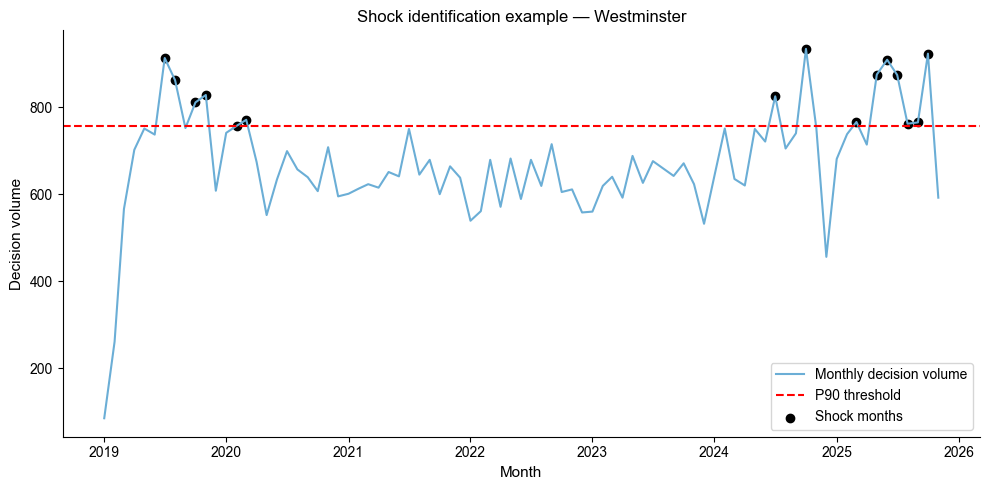

In [5]:
plot_df = df[df["lpa_name"] == example_borough]

p90 = plot_df["p90_volume"].iloc[0]

plt.figure(figsize=(10,5))

plt.plot(
    plot_df["year_month"],
    plot_df["decision_volume"],
    label="Monthly decision volume",
    color="#6BAED6"
)

plt.axhline(
    p90,
    linestyle="--",
    color="red",
    label="P90 threshold"
)

plt.scatter(
    plot_df.loc[plot_df["shock_month"], "year_month"],
    plot_df.loc[plot_df["shock_month"], "decision_volume"],
    color="black",
    label="Shock months"
)

plt.xlabel("Month")
plt.ylabel("Decision volume")
plt.title(f"Shock identification example — {example_borough}")

plt.legend()
plt.tight_layout()
plt.show()

In [6]:
overall_shock_rate = df["shock_month"].mean()

overall_shock_rate

0.10405709992486852

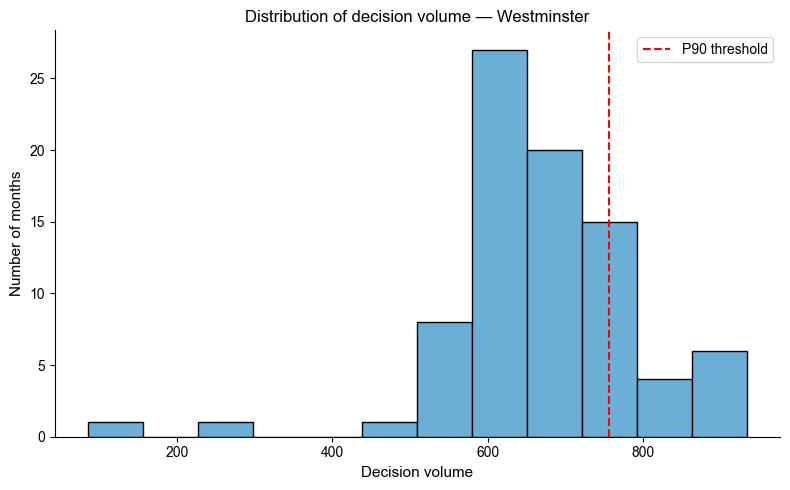

In [7]:
# ---------------------------------
# Distribution of decision volume
# with borough-specific P90 threshold
# ---------------------------------
plot_df = df[df["lpa_name"] == example_borough]

p90 = plot_df["p90_volume"].iloc[0]

plt.figure(figsize=(8,5))

plt.hist(plot_df["decision_volume"], bins=12, color ="#6BAED6", edgecolor="black")
plt.axvline(
    p90,
    linestyle="--",
    color="red",
    label="P90 threshold"
)

plt.xlabel("Decision volume")
plt.ylabel("Number of months")
plt.title(f"Distribution of decision volume — {example_borough}")
plt.legend()
plt.tight_layout()
plt.show()


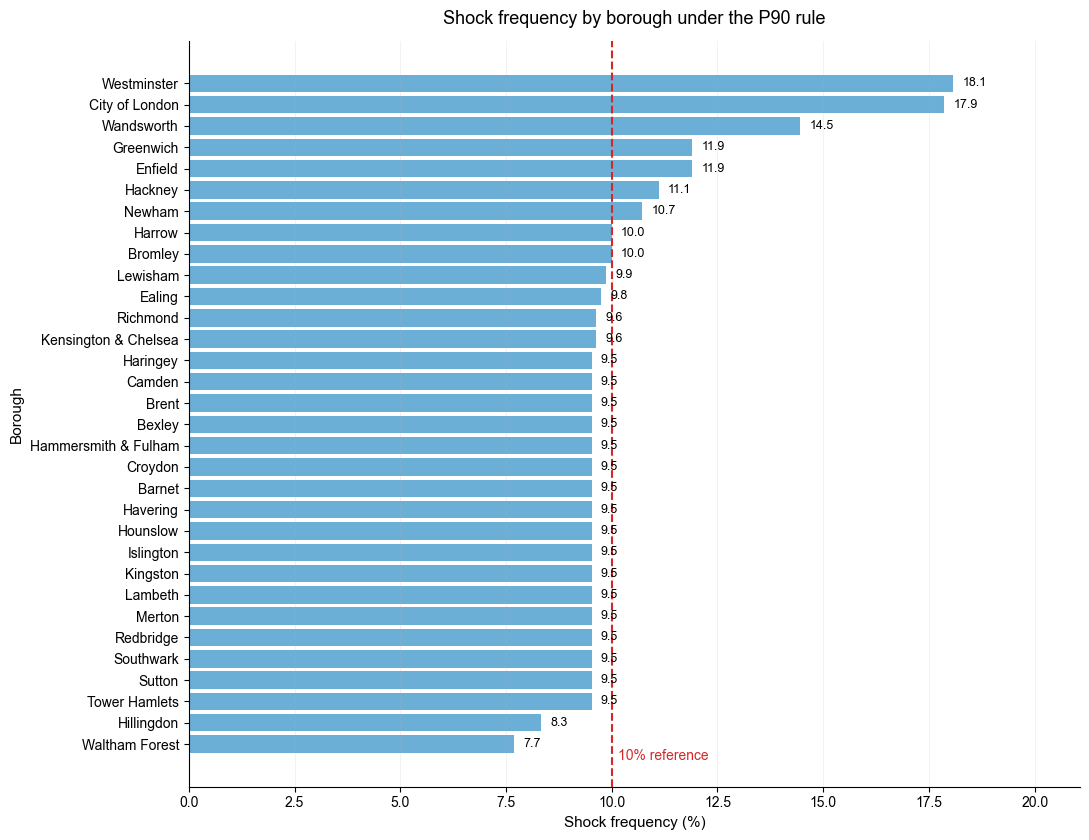

In [8]:
import matplotlib.pyplot as plt
import numpy as np

# ---------------------------------
# Borough-level shock frequency
# ---------------------------------
shock_freq = (
    df.groupby("lpa_name")["shock_month"]
      .mean()
      .sort_values()          # ascending for barh
      .mul(100)
)

# Figure setup
fig, ax = plt.subplots(figsize=(11, 8.5))

bar_color = "#6BAED6"
ref_color = "#D62728"

bars = ax.barh(
    shock_freq.index,
    shock_freq.values,
    color=bar_color,
    edgecolor="none",
    height=0.82
)

# Reference line
ax.axvline(
    10,
    linestyle="--",
    linewidth=1.5,
    color=ref_color,
    zorder=3
)

# Direct annotation for the 10% line (instead of legend)
ax.text(
    10.15,
    -0.9,                     # slightly above the top bar
    "10% reference",
    color=ref_color,
    fontsize=10,
    ha="left",
    va="bottom"
)

# Value labels at end of bars
for bar, value in zip(bars, shock_freq.values):
    ax.text(
        value + 0.22,
        bar.get_y() + bar.get_height() / 2,
        f"{value:.1f}",
        va="center",
        ha="left",
        fontsize=9,
        color="black"
    )

# Axes labels and title
ax.set_xlabel("Shock frequency (%)", fontsize=11)
ax.set_ylabel("Borough", fontsize=11)
ax.set_title("Shock frequency by borough under the P90 rule", fontsize=13, pad=12)

# Gridlines: subtle and only on x-axis
ax.xaxis.grid(True, linestyle="-", linewidth=0.6, alpha=0.18)
ax.yaxis.grid(False)

# Clean spines
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# Tick styling
ax.tick_params(axis="x", labelsize=10)
ax.tick_params(axis="y", labelsize=10)

# Extra room for value labels
ax.set_xlim(0, shock_freq.max() + 3)

plt.tight_layout()
plt.show()

In [9]:
df.groupby("lpa_name")["decision_volume"].describe()

,count,mean,std,min,25%,50%,75%,max
lpa_name,,,,,,,,
Barnet,84.0,542.940476,100.939604,174.0,493.50,542.0,580.00,927.0
Bexley,84.0,216.880952,59.729996,9.0,185.50,217.0,259.50,328.0
Brent,84.0,310.940476,52.893699,189.0,273.50,305.0,344.00,425.0
Bromley,80.0,411.162500,108.172207,1.0,375.75,426.5,458.25,628.0
Camden,84.0,145.250000,57.134775,22.0,107.75,127.0,168.50,292.0
City of London,84.0,86.988095,24.720361,24.0,68.00,86.0,102.00,166.0
Croydon,84.0,371.916667,79.343421,33.0,328.75,361.0,415.25,562.0
Ealing,82.0,388.512195,129.290394,1.0,367.75,403.0,454.75,741.0
Enfield,84.0,309.297619,60.205628,6.0,290.75,311.5,342.25,417.0


In [10]:
df.groupby("lpa_name")["p90_volume"].first()

lpa_name
Barnet                  660.0
Bexley                  292.4
Brent                   385.5
Bromley                 522.4
Camden                  244.8
City of London          103.9
Croydon                 481.7
Ealing                  510.6
Enfield                 361.0
Greenwich               290.7
Hackney                 221.0
Hammersmith & Fulham    279.7
Haringey                287.6
Harrow                  279.3
Havering                342.3
Hillingdon              386.0
Hounslow                394.9
Islington               313.8
Kensington & Chelsea    503.1
Kingston                318.7
Lambeth                 376.5
Lewisham                316.4
Merton                  229.6
Newham                  288.7
Redbridge               464.4
Richmond                461.1
Southwark               366.9
Sutton                  243.9
Tower Hamlets           241.6
Waltham Forest          322.0
Wandsworth              381.0
Westminster             756.5
Name: p90_volume, dtype: float6

In [11]:
import pandas as pd
import matplotlib.pyplot as plt
import geopandas as gpd

# Shock frequency already computed from your panel
shock_map_df = (
    df.groupby("lpa_name")["shock_month"]
      .mean()
      .mul(100)
      .reset_index(name="shock_frequency_pct")
)

In [12]:
# Example: shapefile or GeoJSON with London borough boundaries
boroughs_gdf = gpd.read_file(r"C:\Users\Jose Miguel\OneDrive\Ambiente de Trabalho\NOVA\TESE\notebooks\london_boroughs.geojson")

In [13]:
print(boroughs_gdf.columns)

Index(['name', 'color', 'geometry'], dtype='object')


In [14]:
borough_names_map = set(boroughs_gdf["name"].str.strip().str.lower())
borough_names_df = set(shock_map_df["lpa_name"].str.strip().str.lower())

print("In map but not in df:", sorted(borough_names_map - borough_names_df))
print("In df but not in map:", sorted(borough_names_df - borough_names_map))

In map but not in df: ['barking and dagenham', 'hammersmith and fulham', 'kensington and chelsea', 'kingston upon thames', 'richmond upon thames']
In df but not in map: ['hammersmith & fulham', 'kensington & chelsea', 'kingston', 'richmond']


In [15]:
name_fix = {
    "barking and dagenham": "barking & dagenham",
    "hammersmith and fulham": "hammersmith & fulham",
    "kensington and chelsea": "kensington & chelsea",
    "kingston upon thames": "kingston",
    "richmond upon thames": "richmond"
}

boroughs_gdf["lpa_name"] = (
    boroughs_gdf["name"]
    .str.strip()
    .str.lower()
    .replace(name_fix)
)

In [16]:
shock_map_df["lpa_name"] = shock_map_df["lpa_name"].str.strip().str.lower()

In [17]:
map_df = boroughs_gdf.merge(shock_map_df, on="lpa_name", how="left")

In [18]:
print(map_df[map_df["shock_frequency_pct"].isna()][["name", "lpa_name"]])

                   name            lpa_name
0  Barking and Dagenham  barking & dagenham


In [19]:
map_df["shock_frequency_pct"].isna().sum()

1

C:\Users\Jose Miguel\AppData\Local\Temp\ipykernel_13472\699379155.py:64: UserWarning: Legend does not support handles for PatchCollection instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler
  ax.legend(loc="lower left", frameon=False, fontsize=9)
C:\Users\Jose Miguel\AppData\Local\Temp\ipykernel_13472\699379155.py:64: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(loc="lower left", frameon=False, fontsize=9)


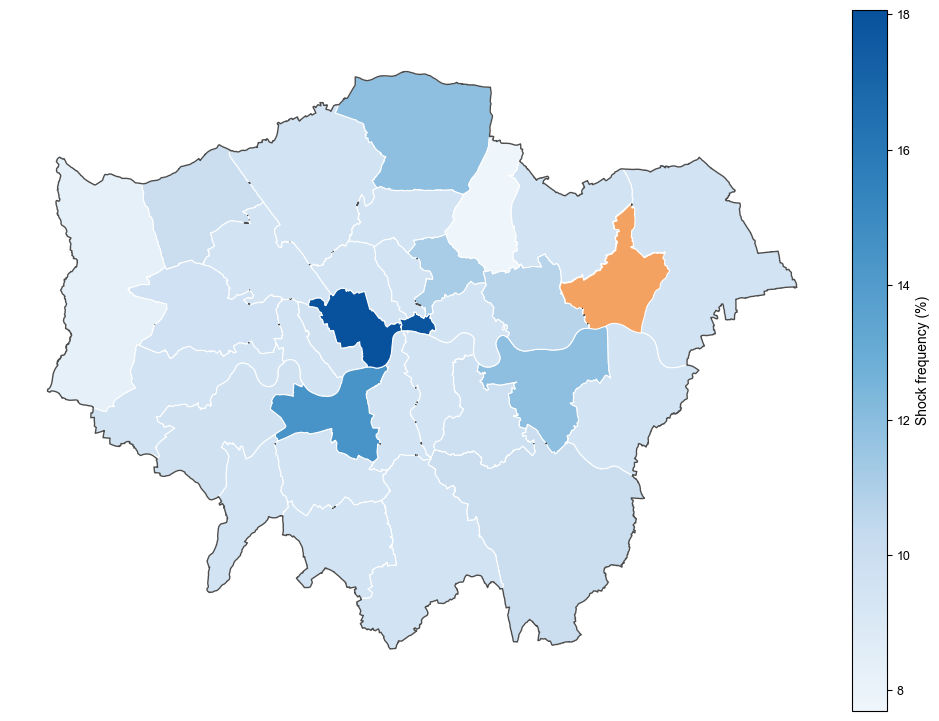

In [20]:
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.colors import LinearSegmentedColormap
import geopandas as gpd

# Custom blue palette
custom_blues = LinearSegmentedColormap.from_list(
    "custom_blues",
    ["#EFF6FB", "#C6DBEF", "#6BAED6", "#3182BD", "#08519C"]
)

# Separate included vs excluded boroughs
included = map_df[map_df["shock_frequency_pct"].notna()].copy()
excluded = map_df[map_df["shock_frequency_pct"].isna()].copy()

fig, ax = plt.subplots(figsize=(9.5, 9.5))

# Plot included boroughs
included.plot(
    column="shock_frequency_pct",
    cmap=custom_blues,
    linewidth=0.8,
    edgecolor="white",
    ax=ax
)

# Plot excluded borough(s) in distinct color
excluded.plot(
    color="#F4A261",
    linewidth=0.8,
    edgecolor="white",
    ax=ax,
    label="Excluded from analysis"
)

# Outer boundary
outline = map_df.dissolve()
geom = outline.geometry.iloc[0]
if geom.geom_type == "MultiPolygon":
    geom = max(geom.geoms, key=lambda g: g.area)

gpd.GeoSeries([geom], crs=map_df.crs).boundary.plot(
    ax=ax,
    color="#4D4D4D",
    linewidth=1.0
)

# Clean axes
ax.set_axis_off()

# Colorbar for included boroughs only
norm = mpl.colors.Normalize(
    vmin=included["shock_frequency_pct"].min(),
    vmax=included["shock_frequency_pct"].max()
)
sm = mpl.cm.ScalarMappable(cmap=custom_blues, norm=norm)
sm._A = []

cbar = fig.colorbar(sm, ax=ax, fraction=0.04, pad=0.02, shrink=0.82)
cbar.set_label("Shock frequency (%)", fontsize=10)
cbar.ax.tick_params(labelsize=9)

# Legend for excluded borough
ax.legend(loc="lower left", frameon=False, fontsize=9)

plt.tight_layout()
plt.show()

In [21]:
sorted(df["lpa_name"].unique())
len(df["lpa_name"].unique())

32

In [22]:
df.groupby("lpa_name")["year_month"].agg(["count", "min", "max"])

,count,min,max
lpa_name,,,
Barnet,84,2019-01-01,2025-12-01
Bexley,84,2019-01-01,2025-12-01
Brent,84,2019-01-01,2025-12-01
Bromley,80,2019-01-01,2025-10-01
Camden,84,2019-01-01,2025-12-01
City of London,84,2019-01-01,2025-12-01
Croydon,84,2019-01-01,2025-12-01
Ealing,82,2019-01-01,2025-11-01
Enfield,84,2019-01-01,2025-12-01


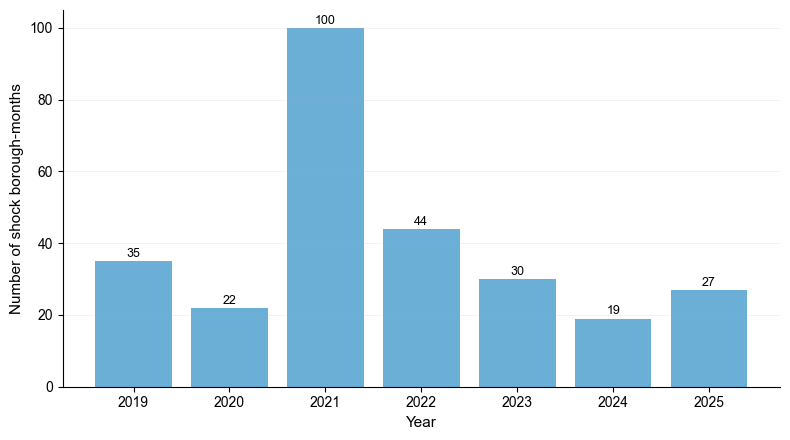

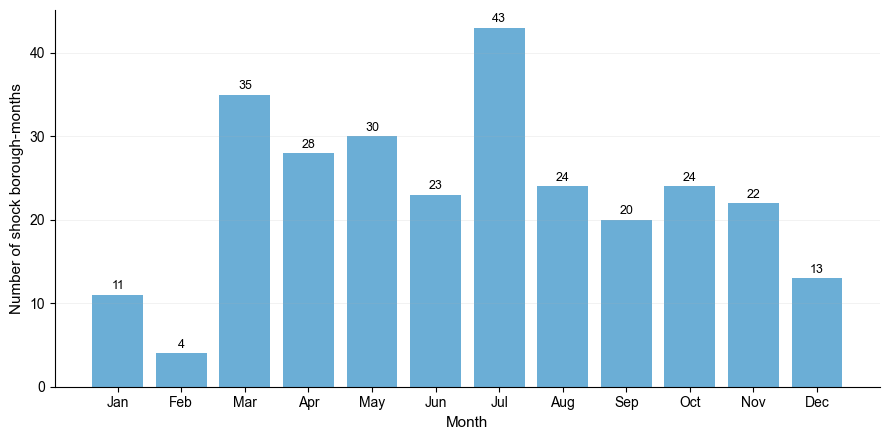

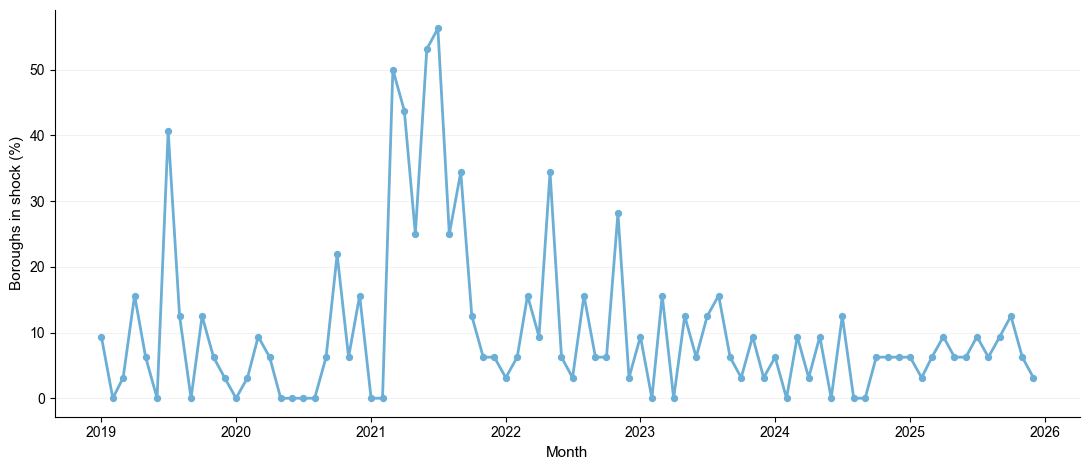

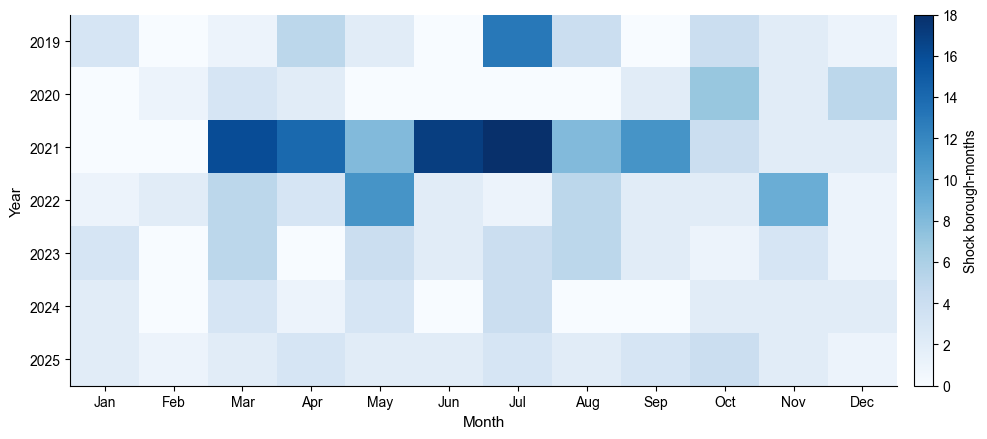


Shocks by year
   year  shock_count
0  2019           35
1  2020           22
2  2021          100
3  2022           44
4  2023           30
5  2024           19
6  2025           27

Shocks by calendar month
   month_name  shock_count
0         Jan           11
1         Feb            4
2         Mar           35
3         Apr           28
4         May           30
5         Jun           23
6         Jul           43
7         Aug           24
8         Sep           20
9         Oct           24
10        Nov           22
11        Dec           13

Monthly share of boroughs in shock (%)
  year_month  shock_boroughs  shock_share_pct
0 2019-01-01               3            9.375
1 2019-02-01               0            0.000
2 2019-03-01               1            3.125
3 2019-04-01               5           15.625
4 2019-05-01               2            6.250

Heatmap table
      Jan  Feb  Mar  Apr  May  Jun  Jul  Aug  Sep  Oct  Nov  Dec
year                                       

In [23]:
# =====================================
# 4.3 Temporal distribution of shocks
# =====================================

import pandas as pd
import matplotlib.pyplot as plt
import calendar

# ------------------------------------------------------------------
# Assumes your final borough-month panel is already loaded in `df`
# Required columns:
#   - year_month
#   - shock_month
# ------------------------------------------------------------------

# Safety
df = df.copy()
df["year_month"] = pd.to_datetime(df["year_month"])

# Time parts
df["year"] = df["year_month"].dt.year
df["month_num"] = df["year_month"].dt.month
df["month_name"] = pd.Categorical(
    df["month_num"].map(lambda x: calendar.month_abbr[x]),
    categories=list(calendar.month_abbr[1:]),
    ordered=True
)

# Keep only shock observations
shock_df = df[df["shock_month"] == 1].copy()

# =====================================
# 1) Shock counts by year
# =====================================
shocks_by_year = (
    shock_df.groupby("year")
    .size()
    .reset_index(name="shock_count")
)

fig, ax = plt.subplots(figsize=(8, 4.5))

bars = ax.bar(
    shocks_by_year["year"].astype(str),
    shocks_by_year["shock_count"],
    color="#6BAED6",
    edgecolor="none"
)

for bar, value in zip(bars, shocks_by_year["shock_count"]):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        value + 0.3,
        f"{int(value)}",
        ha="center",
        va="bottom",
        fontsize=9
    )

ax.set_xlabel("Year", fontsize=11)
ax.set_ylabel("Number of shock borough-months", fontsize=11)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.yaxis.grid(True, linestyle="-", linewidth=0.6, alpha=0.18)
ax.xaxis.grid(False)

plt.tight_layout()
plt.show()

# =====================================
# 2) Shock counts by calendar month
# =====================================
shocks_by_month = (
    shock_df.groupby("month_num")
    .size()
    .reindex(range(1,13), fill_value=0)
    .reset_index(name="shock_count")
)

shocks_by_month["month_name"] = shocks_by_month["month_num"].apply(lambda x: calendar.month_abbr[x])

fig, ax = plt.subplots(figsize=(9, 4.5))

bars = ax.bar(
    shocks_by_month["month_name"],
    shocks_by_month["shock_count"],
    color="#6BAED6",
    edgecolor="none"
)

for bar in bars:
    height = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        height + 0.3,
        f"{int(height)}",
        ha="center",
        va="bottom",
        fontsize=9
    )

ax.set_xlabel("Month", fontsize=11)
ax.set_ylabel("Number of shock borough-months", fontsize=11)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.yaxis.grid(True, linestyle="-", linewidth=0.6, alpha=0.18)
ax.xaxis.grid(False)

plt.tight_layout()
plt.show()

# =====================================
# 3) Share of boroughs in shock by month-year
# =====================================
borough_count = df["lpa_name"].nunique()

shocks_month_year = (
    df.groupby("year_month")["shock_month"]
    .sum()
    .reset_index(name="shock_boroughs")
)

shocks_month_year["shock_share_pct"] = (
    shocks_month_year["shock_boroughs"] / borough_count * 100
)

fig, ax = plt.subplots(figsize=(11, 4.8))

ax.plot(
    shocks_month_year["year_month"],
    shocks_month_year["shock_share_pct"],
    color="#6BAED6",
    linewidth=2
)

ax.scatter(
    shocks_month_year["year_month"],
    shocks_month_year["shock_share_pct"],
    color="#6BAED6",
    s=18
)

ax.set_xlabel("Month", fontsize=11)
ax.set_ylabel("Boroughs in shock (%)", fontsize=11)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.yaxis.grid(True, linestyle="-", linewidth=0.6, alpha=0.18)
ax.xaxis.grid(False)

plt.tight_layout()
plt.show()

# =====================================
# 4) Heatmap: number of boroughs in shock by month and year
# =====================================
heatmap_df = (
    df.groupby(["year", "month_num"])["shock_month"]
    .sum()
    .unstack(fill_value=0)
)

heatmap_df = heatmap_df.reindex(columns=range(1, 13))
heatmap_df.columns = [calendar.month_abbr[m] for m in heatmap_df.columns]

fig, ax = plt.subplots(figsize=(10, 4.5))

im = ax.imshow(heatmap_df.values, aspect="auto", cmap="Blues")

ax.set_xticks(range(len(heatmap_df.columns)))
ax.set_xticklabels(heatmap_df.columns)
ax.set_yticks(range(len(heatmap_df.index)))
ax.set_yticklabels(heatmap_df.index)

ax.set_xlabel("Month", fontsize=11)
ax.set_ylabel("Year", fontsize=11)

cbar = plt.colorbar(im, ax=ax, fraction=0.035, pad=0.02)
cbar.set_label("Shock borough-months", fontsize=10)

plt.tight_layout()
plt.show()

# =====================================
# 5) Tables for writing
# =====================================
print("\nShocks by year")
print(shocks_by_year)

print("\nShocks by calendar month")
print(shocks_by_month[["month_name", "shock_count"]])

print("\nMonthly share of boroughs in shock (%)")
print(shocks_month_year.head())

print("\nHeatmap table")
print(heatmap_df)

In [24]:
df["resilience_index"].describe()

count    2.662000e+03
mean    -1.276761e-11
std      7.212195e-01
min     -1.899415e+01
25%     -1.426770e-01
50%      5.798244e-02
75%      2.614828e-01
max      3.242195e+00
Name: resilience_index, dtype: float64

<Axes: >

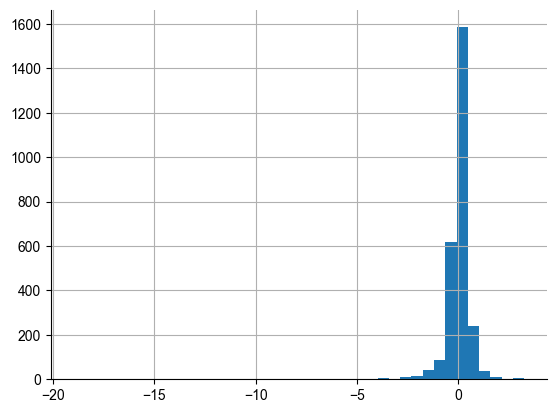

In [25]:
df["resilience_index"].hist(bins=40)

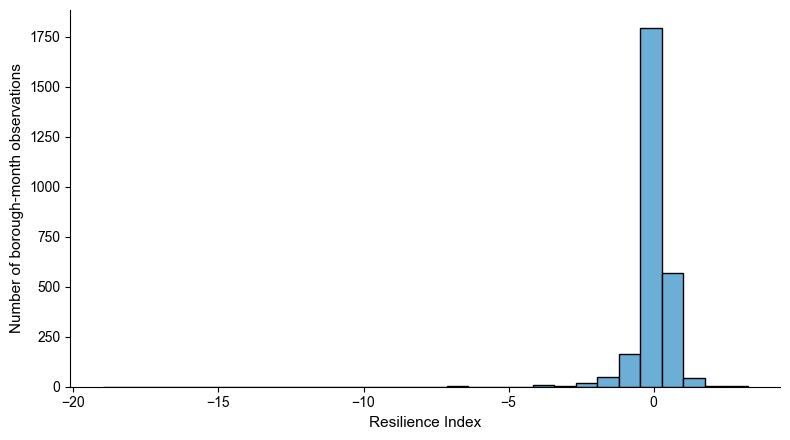

In [36]:
df = df.dropna(subset=["resilience_index"]).copy()

plt.figure(figsize=(8,4.5))
plt.hist(df["resilience_index"], color="#6BAED6", bins=30, edgecolor="black")
plt.xlabel("Resilience Index")
plt.ylabel("Number of borough-month observations")
plt.tight_layout()
plt.show()

In [27]:
borough_ri = (
    df.groupby("lpa_name")["resilience_index"]
         .mean()
         .sort_values(ascending=False)
         .reset_index()
)

borough_ri

,lpa_name,resilience_index
0,Islington,0.283104
1,Croydon,0.193537
2,Hounslow,0.176933
3,Hillingdon,0.158685
4,Camden,0.156191
5,Enfield,0.142669
6,Brent,0.142326
7,Kingston,0.131595
8,Barnet,0.118427
9,Richmond,0.109567


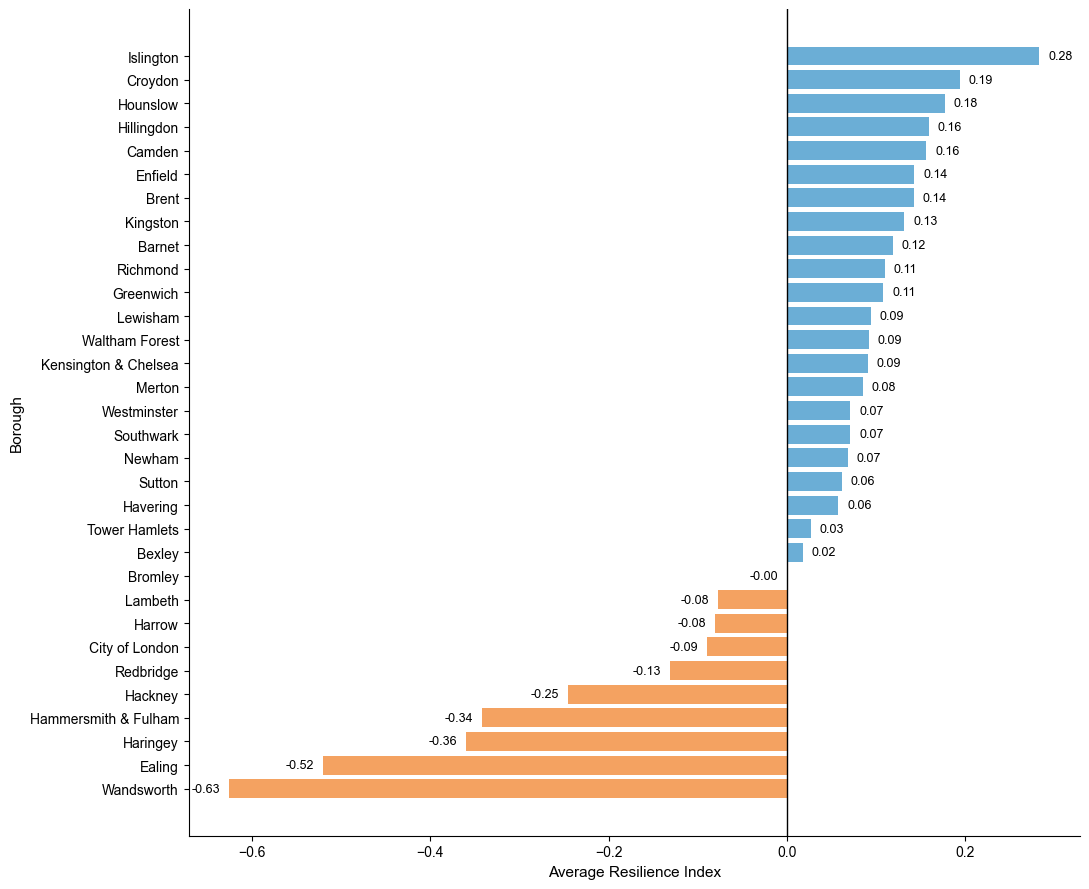

In [38]:
import matplotlib.pyplot as plt

borough_ri = (
    df.groupby("lpa_name")["resilience_index"]
      .mean()
      .sort_values()
      .reset_index()
)

colors = ["#F4A261" if v < 0 else "#6BAED6" for v in borough_ri["resilience_index"]]

plt.figure(figsize=(11,9))

bars = plt.barh(
    borough_ri["lpa_name"],
    borough_ri["resilience_index"],
    color=colors,
    edgecolor="none"
)

plt.axvline(0, color="black", linewidth=1)

plt.xlabel("Average Resilience Index")
plt.ylabel("Borough")

for bar, value in zip(bars, borough_ri["resilience_index"]):
    plt.text(
        value + 0.01 if value >= 0 else value - 0.01,
        bar.get_y() + bar.get_height()/2,
        f"{value:.2f}",
        va="center",
        ha="left" if value >= 0 else "right",
        fontsize=9
    )

plt.tight_layout()
plt.show()

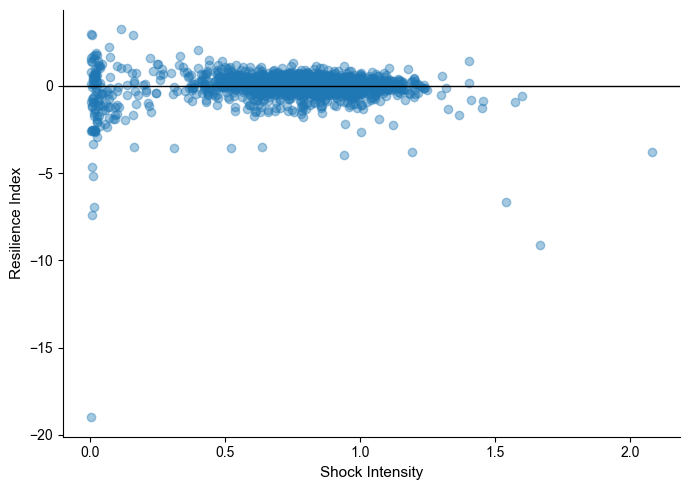

In [29]:
plt.figure(figsize=(7,5))

plt.scatter(
    df["shock_intensity"],
    df["resilience_index"],
    alpha=0.4
)

plt.axhline(0, color="black", linewidth=1)

plt.xlabel("Shock Intensity")
plt.ylabel("Resilience Index")

plt.tight_layout()
plt.show()

In [30]:
df.nsmallest(10, "resilience_index")[[
    "lpa_name",
    "year_month",
    "impact_mdt",
    "impact_ar",
    "resilience_index",
    "shock_intensity"
]]

,lpa_name,year_month,impact_mdt,impact_ar,resilience_index,shock_intensity
2615,Ealing,2025-11-01,701.0,0.663771,-18.994148,0.001958
682,Hammersmith & Fulham,2020-10-01,302.0,0.470026,-9.133348,1.666071
286,Wandsworth,2019-09-01,363.5,-0.109023,-7.405903,0.005249
94,Wandsworth,2019-03-01,343.5,-0.109023,-6.963419,0.013123
2396,Wandsworth,2025-03-01,312.5,-0.037473,-6.659148,1.540682
797,Wandsworth,2021-01-01,263.0,-0.109023,-5.182421,0.010499
350,Wandsworth,2019-11-01,-1.5,0.890977,-4.663596,0.005249
1770,Hammersmith & Fulham,2023-08-01,107.0,0.310983,-3.970950,0.940293
650,Hammersmith & Fulham,2020-09-01,94.0,0.334607,-3.809325,1.190561
746,Hammersmith & Fulham,2020-12-01,51.0,0.510113,-3.793959,2.080801


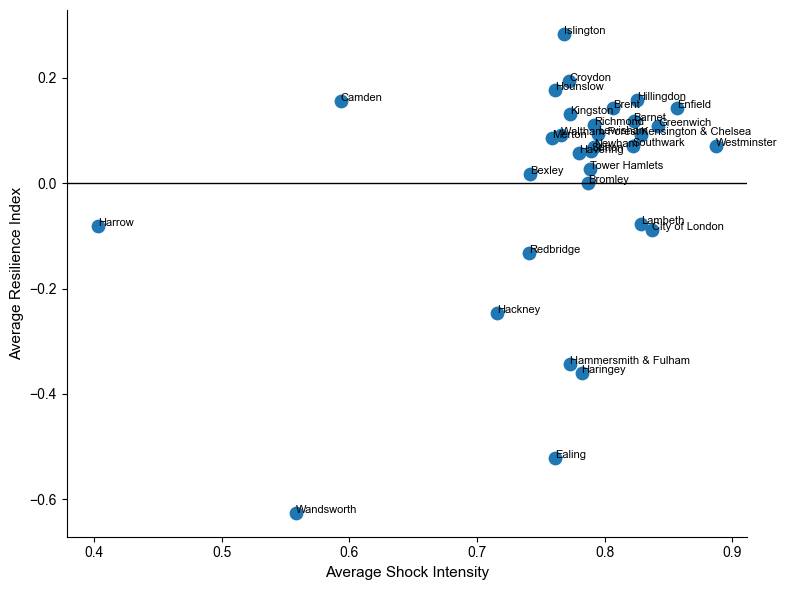

In [31]:
borough_diag = (
    df.groupby("lpa_name")
      .agg(
          avg_shock=("shock_intensity","mean"),
          avg_resilience=("resilience_index","mean")
      )
      .reset_index()
)

plt.figure(figsize=(8,6))

plt.scatter(
    borough_diag["avg_shock"],
    borough_diag["avg_resilience"],
    s=80
)

for i,row in borough_diag.iterrows():
    plt.text(
        row["avg_shock"],
        row["avg_resilience"],
        row["lpa_name"],
        fontsize=8
    )

plt.axhline(0,color="black",linewidth=1)

plt.xlabel("Average Shock Intensity")
plt.ylabel("Average Resilience Index")

plt.tight_layout()
plt.show()

In [32]:
df[df["impact_mdt"] > 500][[
    "lpa_name",
    "year_month",
    "median_decision_time",
    "baseline_mdt",
    "impact_mdt"
]]

,lpa_name,year_month,median_decision_time,baseline_mdt,impact_mdt
2615,Ealing,2025-11-01,755.0,54.0,701.0


### Experimentations

In [ ]:
"""
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# -----------------------------
# Load
# -----------------------------
df["year_month"] = pd.to_datetime(df["year_month"])

TRAIN_START = "2019-01-01"
TRAIN_END   = "2024-12-31"

train = df[(df["year_month"] >= TRAIN_START) & (df["year_month"] <= TRAIN_END)].copy()

# -----------------------------
# Build borough-level profile table
# -----------------------------
# Use shock_month if present; otherwise use shock_flag
shock_col = "shock_month" if "shock_month" in train.columns else "shock_flag"

profile = (
    train.groupby("lpa_name")
    .apply(lambda g: pd.Series({
        # Core performance
        "MDT_avg": g["median_decision_time"].mean(),
        "AR_avg":  g["approval_rate"].mean(),
        "VOL_avg": g["decision_volume"].mean(),

        # Shock exposure
        "Shock_rate": g[shock_col].astype(int).mean(),
        "Shock_intensity_avg": g.loc[g[shock_col].astype(bool), "shock_intensity"].mean()
            if (g[shock_col].astype(int).sum() > 0) else 0.0,

        # Deterioration during shocks (impacts)
        "Impact_MDT_shock_avg": g.loc[g[shock_col].astype(bool), "impact_mdt"].mean()
            if (g[shock_col].astype(int).sum() > 0) else 0.0,
        "Impact_AR_shock_avg": g.loc[g[shock_col].astype(bool), "impact_ar"].mean()
            if (g[shock_col].astype(int).sum() > 0) else 0.0,
    }))
    .reset_index()
)

# -----------------------------
# Choose radar dimensions
# IMPORTANT: higher should mean "better" for a clean radar.
# So we flip MDT and the impacts (because higher = worse).
# -----------------------------
dims = [
    "Speed (low MDT)",          # from MDT_avg (flipped)
    "Approval rate",            # AR_avg
    "Workload (volume)",        # VOL_avg
    "Shock exposure",           # Shock_rate
    "Robustness (MDT impact)",  # Impact_MDT_shock_avg (flipped)
    "Robustness (AR impact)",   # Impact_AR_shock_avg (flipped)
]

# Pull raw columns in same order:
raw_cols = [
    "MDT_avg",
    "AR_avg",
    "VOL_avg",
    "Shock_rate",
    "Impact_MDT_shock_avg",
    "Impact_AR_shock_avg",
]

# Convert to "higher = better" space
# - Speed: lower MDT better => invert
# - Robustness: lower impact better => invert
# AR and volume and shock_rate: depends on interpretation
#   Here: higher volume is "more workload" (not better or worse), but keep as "scale of activity"
#   Shock_rate: higher means more exposure; not "better" but still useful as a profile axis
#   If you want "less exposure is better", flip Shock_rate too.
profile_adj = profile.copy()
profile_adj["MDT_avg"] = -profile_adj["MDT_avg"]
profile_adj["Impact_MDT_shock_avg"] = -profile_adj["Impact_MDT_shock_avg"]
profile_adj["Impact_AR_shock_avg"]  = -profile_adj["Impact_AR_shock_avg"]

# OPTIONAL: if you want "less shock exposure is better", uncomment:
# profile_adj["Shock_rate"] = -profile_adj["Shock_rate"]

# -----------------------------
# Min-max scale to [0,1] per dimension
# -----------------------------
scaled = profile_adj.copy()
for c in raw_cols:
    mn, mx = scaled[c].min(), scaled[c].max()
    if np.isclose(mx - mn, 0):
        scaled[c] = 0.5
    else:
        scaled[c] = (scaled[c] - mn) / (mx - mn)

# -----------------------------
# Radar plotting helper
# -----------------------------
def radar_plot(df_scaled, boroughs, title):
    k = len(raw_cols)
    angles = np.linspace(0, 2*np.pi, k, endpoint=False).tolist()
    angles += angles[:1]

    fig = plt.figure(figsize=(9, 9))
    ax = plt.subplot(111, polar=True)

    ax.set_theta_offset(np.pi / 2)
    ax.set_theta_direction(-1)

    ax.set_thetagrids(np.degrees(angles[:-1]), dims)
    ax.set_ylim(0, 1)

    for b in boroughs:
        row = df_scaled[df_scaled["lpa_name"] == b]
        if row.empty:
            continue
        vals = row[raw_cols].values.flatten().tolist()
        vals += vals[:1]
        ax.plot(angles, vals, linewidth=2, label=b)
        ax.fill(angles, vals, alpha=0.08)

    ax.set_title(title, pad=20)
    ax.legend(loc="upper right", bbox_to_anchor=(1.25, 1.10))
    plt.show()

# -----------------------------
# Radar 1: Top vs Bottom by avg MDT (train)
# -----------------------------
tmp = profile.sort_values("MDT_avg", ascending=True)  # lower MDT = better
best3 = tmp["lpa_name"].head(3).tolist()
worst3 = tmp["lpa_name"].tail(3).tolist()
radar_plot(scaled, best3 + worst3, "Borough profiles — Best vs worst (avg median decision time, 2019–2024)")

# -----------------------------
# Radar 2: Your chosen boroughs (edit list)
# -----------------------------
example = ["Camden", "Westminster", "Hackney", "Newham", "Croydon", "Barnet"]
radar_plot(scaled, example, "Borough profiles — Selected examples (2019–2024)")

# -----------------------------
# Radar 3: “Resilience under shocks” — lowest deterioration during shock months
#   Here we rank by impact during shocks (lower is better).
# -----------------------------
res_rank = profile.sort_values(["Impact_MDT_shock_avg", "Impact_AR_shock_avg"], ascending=True)
best_shock3 = res_rank["lpa_name"].head(3).tolist()
worst_shock3 = res_rank["lpa_name"].tail(3).tolist()
radar_plot(scaled, best_shock3 + worst_shock3, "Borough profiles — Best vs worst resilience under shocks (2019–2024)")
"""

In [ ]:
"""
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# -----------------------------
# Load + basic prep
# -----------------------------
df = pd.read_csv(r"C:\Users\Jose Miguel\OneDrive\Ambiente de Trabalho\NOVA\TESE\processed\borough_month_panel_resilience_inputs.csv")
df["year_month"] = pd.to_datetime(df["year_month"])
df["year"] = df["year_month"].dt.year

COL_VOL = "decision_volume"
COL_MDT = "median_decision_time"
COL_AR  = "approval_rate"

# hard filter to thesis scope for main figures
df_19_25 = df[(df["year_month"] >= "2019-01-01") & (df["year_month"] <= "2025-12-01")].copy()

def weighted_mean(g, value_col, weight_col):
    w = g[weight_col].astype(float).to_numpy()
    v = g[value_col].astype(float).to_numpy()
    s = np.nansum(w)
    if s == 0:
        return np.nan
    return np.average(v, weights=w)

def london_aggregate(d):
    out = (
        d.groupby("year_month", as_index=False)
         .apply(lambda g: pd.Series({
             "london_volume": g[COL_VOL].sum(),
             "london_mdt_wmean": weighted_mean(g, COL_MDT, COL_VOL),
             "london_ar_wmean":  weighted_mean(g, COL_AR,  COL_VOL),
         }))
         .reset_index(drop=True)
    )
    return out

london_full  = london_aggregate(df)       # for the one context plot if you want
london_19_25 = london_aggregate(df_19_25) # for thesis main plots

# -----------------------------
# Plot style (simple, consistent)
# -----------------------------
LINE_COLOR = "#6BAED6"   # light blue
GRID_ALPHA = 0.25

def base_axes(title, xlabel="Month"):
    fig = plt.figure(figsize=(9,4.5))
    ax = plt.gca()
    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.grid(True, alpha=GRID_ALPHA)
    return fig, ax

def shade_scope(ax, start="2019-01-01", end="2025-12-31"):
    ax.axvspan(pd.to_datetime(start), pd.to_datetime(end), alpha=0.10)

# -----------------------------
# (A) One context plot (optional): 2010–2025 volume + shade 2019–2025
# -----------------------------
fig, ax = base_axes("London aggregate — Decision volume (monthly) with 2019 window highlighted")
ax.plot(london_full["year_month"], london_full["london_volume"], linewidth=2, color=LINE_COLOR)
shade_scope(ax, "2019-01-01", "2025-12-31")
ax.set_ylabel("Decision volume (sum across boroughs)")
plt.tight_layout()
plt.show()

# -----------------------------
# (B) Thesis main plots: 2019–2025 only
# -----------------------------
fig, ax = base_axes("London aggregate — Decision volume (monthly), 2019–2025")
ax.plot(london_19_25["year_month"], london_19_25["london_volume"], linewidth=2, color=LINE_COLOR)
ax.set_ylabel("Decision volume (sum across boroughs)")
plt.tight_layout()
plt.show()

fig, ax = base_axes("London aggregate — Decision time (volume-weighted mean of borough medians), 2019–2025")
ax.plot(london_19_25["year_month"], london_19_25["london_mdt_wmean"], linewidth=2, color=LINE_COLOR)
ax.set_ylabel("Decision time (days; volume-weighted mean)")
plt.tight_layout()
plt.show()

fig, ax = base_axes("London aggregate — Approval rate (volume-weighted mean), 2019–2025")
ax.plot(london_19_25["year_month"], london_19_25["london_ar_wmean"], linewidth=2, color=LINE_COLOR)
ax.set_ylabel("Approval rate (volume-weighted mean)")
ax.set_ylim(0, 1)
plt.tight_layout()
plt.show()

# -----------------------------
# (C) Distribution (keep ONLY volume histogram for Step 1)
# -----------------------------
fig, ax = base_axes("Distribution — Decision volume (all borough-months, 2019–2025)", xlabel="Decision volume")
ax.hist(df_19_25[COL_VOL].dropna(), bins=40, edgecolor="none")
ax.set_ylabel("Count")
plt.tight_layout()
plt.show()

# -----------------------------
# (D) Example boroughs (keep ONLY MDT)
# Choose top boroughs by total volume in 2019–2025 (or manually specify)
# -----------------------------
top_boroughs = (
    df_19_25.groupby("lpa_name")[COL_VOL].sum()
           .sort_values(ascending=False)
           .head(6)
           .index.tolist()
)

df_ex = df_19_25[df_19_25["lpa_name"].isin(top_boroughs)].copy()

fig, ax = base_axes("Selected boroughs — Median decision time (monthly), 2019–2025")
for b in top_boroughs:
    sub = df_ex[df_ex["lpa_name"] == b]
    ax.plot(sub["year_month"], sub[COL_MDT], linewidth=1.8, label=b)
ax.set_ylabel("Median decision time (days)")
ax.legend(loc="upper left", frameon=False)
plt.tight_layout()
plt.show()

print("Selected boroughs used:", top_boroughs)
"""